# Import Library

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

print("PyTorch:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.13.0+cpu
Device: cpu


# Load Dataset

In [18]:
# Dataset menggunakan delimiter ';' dan baris pertama adalah judul dataset
data = pd.read_csv(
    "gsar_a_2521295_sm1572.csv",
    sep=";",
    skiprows=1,
    encoding="utf-8-sig"
)

# Buang baris dengan SMILES kosong (jika ada) & pastikan label integer
data = data.dropna(subset=["SMILES", "label"]).reset_index(drop=True)
data["label"] = data["label"].astype(int)

print(data.shape)
data[["compound ID", "SMILES", "label"]].head()

(846, 8)


,compound ID,SMILES,label
0,A001,FC1(F)CN(c2c(C(F)(F)F)cnc3[nH]c(C4=CCNC4)cc23)C1,1
1,A002,CC(C)[C@@H](NC(=O)c1cc(-c2cnn3cc(-c4ccc(OCCN5C...,1
2,A003,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCCNC4)cc3...,1
3,A004,CN1CC=C(c2cc3cc(-c4csc(C(=O)NCC(F)(F)F)c4)cnc3...,1
4,A005,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCNCC4)cc3...,1


# Split Train/Test

In [19]:
X_smiles = data["SMILES"].values
y = data["label"].values.reshape(-1, 1)

X_train_smiles, X_test_smiles, Y_train, Y_test = train_test_split(
    X_smiles, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(X_train_smiles.shape, X_test_smiles.shape)

(592,) (254,)


# Tokenisasi SMILES

In [20]:
# Bangun charset dari SELURUH data (train saja untuk hindari kebocoran info test,
# tapi tambahkan token start '!' dan end 'E')
charset = set("".join(list(X_train_smiles)) + "!E")
char_to_int = dict((c, i) for i, c in enumerate(charset))
int_to_char = dict((i, c) for i, c in enumerate(charset))

embed = max([len(smile) for smile in X_smiles]) + 5
vocab_size = len(charset)

print("Jumlah karakter unik (vocab_size):", vocab_size)
print("Panjang embedding (embed):", embed)

Jumlah karakter unik (vocab_size): 33
Panjang embedding (embed): 102


In [21]:
def vectorize(smiles, charset, char_to_int, embed):
    one_hot = np.zeros((smiles.shape[0], embed, len(charset)), dtype=np.int8)
    for i, smile in enumerate(smiles):
        # encode start char
        one_hot[i, 0, char_to_int["!"]] = 1
        # encode karakter SMILES
        for j, c in enumerate(smile):
            if c in char_to_int:
                one_hot[i, j + 1, char_to_int[c]] = 1
        # encode end char (padding sisa)
        one_hot[i, len(smile) + 1:, char_to_int["E"]] = 1
    # kembalikan input (X) saja, sesuai kebutuhan baseline LSTM
    return one_hot[:, 0:-1, :]

X_train_onehot = vectorize(X_train_smiles, charset, char_to_int, embed)
X_test_onehot  = vectorize(X_test_smiles, charset, char_to_int, embed)

# Ubah one-hot menjadi integer sequence untuk input layer Embedding
X_train = np.argmax(X_train_onehot, axis=2)
X_test  = np.argmax(X_test_onehot, axis=2)

print(X_train.shape, X_test.shape)

(592, 101) (254, 101)


# Dataset & Dataset Loader

In [22]:
class SmilesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)      # integer sequence untuk Embedding
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SmilesDataset(X_train, Y_train)
test_dataset  = SmilesDataset(X_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Pembentukan model Baseline

In [23]:
class LSTMBaseline(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, units_list=[64]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm_layers = nn.ModuleList()
        input_size = embedding_dim
        for units in units_list:
            self.lstm_layers.append(
                nn.LSTM(input_size=input_size, hidden_size=units, batch_first=True)
            )
            input_size = units

        self.output_layer = nn.Linear(units_list[-1], 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.embedding(x)          # (batch, seq_len, embedding_dim) — seq_len otomatis mengikuti input
        for lstm in self.lstm_layers:
            out, _ = lstm(out)
        out = out[:, -1, :]
        out = self.output_layer(out)
        return self.sigmoid(out)


# Konfigurasi Tabel 3
baseline_configs = {
    "Baseline 1": [64],
    "Baseline 2": [64, 128],
    "Baseline 3": [64, 128, 256],
}

# Train Baseline Model

In [24]:
def train_model(model, train_loader, test_loader, epochs=50, lr=0.001, device=device):
    model.to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
            train_correct += ((preds > 0.5).float() == yb).sum().item()
            train_total += xb.size(0)

        # ---- Validasi ----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)

                val_loss += loss.item() * xb.size(0)
                val_correct += ((preds > 0.5).float() == yb).sum().item()
                val_total += xb.size(0)

        history["loss"].append(train_loss / train_total)
        history["accuracy"].append(train_correct / train_total)
        history["val_loss"].append(val_loss / val_total)
        history["val_accuracy"].append(val_correct / val_total)

        print(f"Epoch {epoch+1}/{epochs} - "
              f"loss: {history['loss'][-1]:.4f} - acc: {history['accuracy'][-1]:.4f} - "
              f"val_loss: {history['val_loss'][-1]:.4f} - val_acc: {history['val_accuracy'][-1]:.4f}")

    return history

In [25]:
histories = {}
models = {}

for name, units_list in baseline_configs.items():
    print(f"\n=== Melatih {name} | LSTM layers: {units_list} ===")

    model = LSTMBaseline(
        vocab_size=vocab_size,
        embedding_dim=50,
        units_list=units_list
    )

    history = train_model(model, train_loader, test_loader, epochs=50, lr=0.001)

    histories[name] = history
    models[name] = model

    # Simpan bobot terbaik (opsional, mirip ModelCheckpoint)
    torch.save(model.state_dict(), f"weights.best.{name.replace(' ', '_')}.pt")


=== Melatih Baseline 1 | LSTM layers: [64] ===
Epoch 1/50 - loss: 0.7009 - acc: 0.4713 - val_loss: 0.6966 - val_acc: 0.4961
Epoch 2/50 - loss: 0.6937 - acc: 0.5118 - val_loss: 0.6962 - val_acc: 0.5039
Epoch 3/50 - loss: 0.6943 - acc: 0.5017 - val_loss: 0.6928 - val_acc: 0.5157
Epoch 4/50 - loss: 0.6945 - acc: 0.5084 - val_loss: 0.6930 - val_acc: 0.4961
Epoch 5/50 - loss: 0.6931 - acc: 0.5068 - val_loss: 0.6924 - val_acc: 0.5157
Epoch 6/50 - loss: 0.6916 - acc: 0.5405 - val_loss: 0.6879 - val_acc: 0.4961
Epoch 7/50 - loss: 0.6673 - acc: 0.6807 - val_loss: 0.6291 - val_acc: 0.6969
Epoch 8/50 - loss: 0.5555 - acc: 0.7686 - val_loss: 0.4790 - val_acc: 0.7874
Epoch 9/50 - loss: 0.4816 - acc: 0.7889 - val_loss: 0.4437 - val_acc: 0.7992
Epoch 10/50 - loss: 0.4455 - acc: 0.8057 - val_loss: 0.4142 - val_acc: 0.8150
Epoch 11/50 - loss: 0.4511 - acc: 0.8226 - val_loss: 0.4052 - val_acc: 0.8268
Epoch 12/50 - loss: 0.4031 - acc: 0.8361 - val_loss: 0.4012 - val_acc: 0.8228
Epoch 13/50 - loss: 0.385

# fungsi yang Mengambil hasil Prediksi

In [ ]:
def get_predictions(model, data_loader, device=device, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            probs = model(xb).cpu().numpy().flatten()
            preds = (probs >= threshold).astype(int)

            y_true.extend(yb.numpy().flatten().astype(int))
            y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

In [ ]:
def compute_confusion_matrix(y_true, y_pred):
    """
    Menghitung TP, TN, FP, FN sesuai struktur Tabel 6:
                        Prediksi Aktif(1)   Prediksi Inaktif(0)
    Aktual Aktif(1)     TP                  FN
    Aktual Inaktif(0)   FP                  TN
    """
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return TP, TN, FP, FN

In [ ]:
def compute_metrics(TP, TN, FP, FN, eps=1e-10):
    # Persamaan 12 - Accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN + eps)

    # Persamaan 13 - Recall
    recall = TP / (TP + FN + eps)

    # Persamaan 14 - Precision
    precision = TP / (TP + FP + eps)

    # Persamaan 15 - F1-Score
    f1_score = 2 * (precision * recall) / (precision + recall + eps)

    return {
        "accuracy": accuracy,
        "recall": recall,
        "precision": precision,
        "f1_score": f1_score
    }

In [ ]:
def print_confusion_matrix(TP, TN, FP, FN, model_name=""):
    cm_df = pd.DataFrame(
        [[TP, FN], [FP, TN]],
        index=["Aktual Aktif (1)", "Aktual Inaktif (0)"],
        columns=["Prediksi Aktif (1)", "Prediksi Inaktif (0)"]
    )
    print(f"\nConfusion Matrix - {model_name}")
    print(cm_df)
    return cm_df

In [ ]:
import seaborn as sns

def plot_confusion_matrix(TP, TN, FP, FN, model_name=""):
    cm = np.array([[TP, FN], [FP, TN]])
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Prediksi Aktif (1)", "Prediksi Inaktif (0)"],
                yticklabels=["Aktual Aktif (1)", "Aktual Inaktif (0)"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("Kelas Aktual")
    plt.xlabel("Kelas Prediksi")
    plt.tight_layout()
    plt.show()

# COmpare performa Model

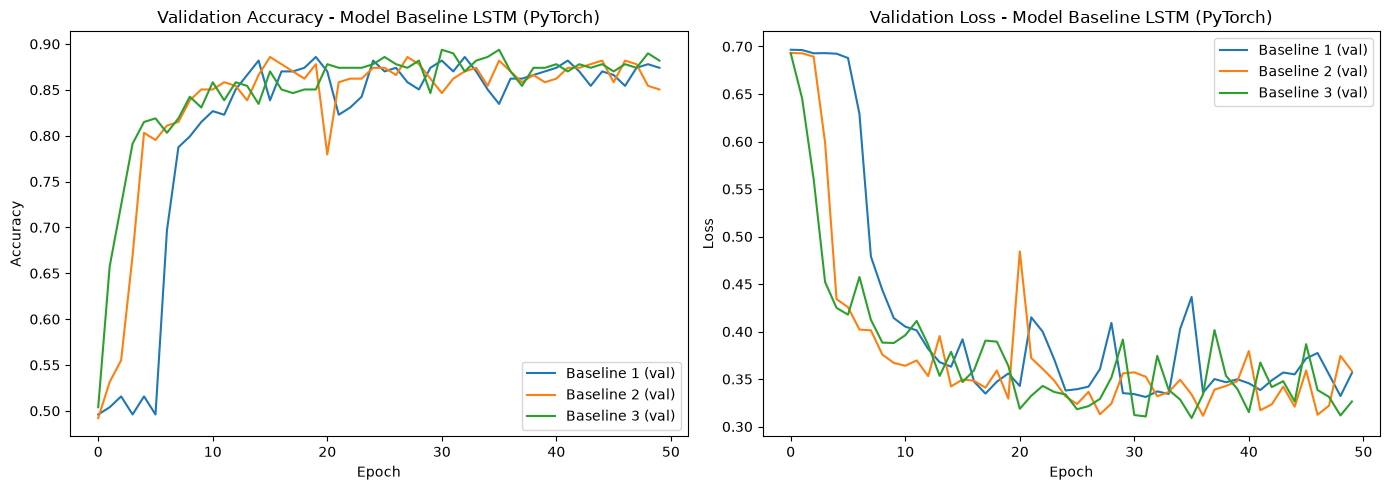

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, hist in histories.items():
    plt.plot(hist["val_accuracy"], label=f"{name} (val)")
plt.title("Validation Accuracy - Model Baseline LSTM (PyTorch)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
for name, hist in histories.items():
    plt.plot(hist["val_loss"], label=f"{name} (val)")
plt.title("Validation Loss - Model Baseline LSTM (PyTorch)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
evaluation_results = {}

for name, model in models.items():
    y_true, y_pred = get_predictions(model, test_loader, device=device)

    TP, TN, FP, FN = compute_confusion_matrix(y_true, y_pred)
    metrics = compute_metrics(TP, TN, FP, FN)

    print_confusion_matrix(TP, TN, FP, FN, model_name=name)
    plot_confusion_matrix(TP, TN, FP, FN, model_name=name)

    print(f"Accuracy  : {metrics['accuracy']:.4f}")
    print(f"Recall    : {metrics['recall']:.4f}")
    print(f"Precision : {metrics['precision']:.4f}")
    print(f"F1-Score  : {metrics['f1_score']:.4f}")

    evaluation_results[name] = {
        "TP": TP, "TN": TN, "FP": FP, "FN": FN,
        **metrics
    }

In [ ]:
# Ringkasan hasil akhir tiap baseline (epoch terakhir)
summary = pd.DataFrame({
    name: {
        "train_acc": hist["accuracy"][-1],
        "val_acc": hist["val_accuracy"][-1],
        "train_loss": hist["loss"][-1],
        "val_loss": hist["val_loss"][-1],
    }
    for name, hist in histories.items()
}).T

summary

summary_df = pd.DataFrame(evaluation_results).T
summary_df = summary_df[["TP", "TN", "FP", "FN", "accuracy", "recall", "precision", "f1_score"]]
summary_df

,train_acc,val_acc,train_loss,val_loss
Baseline 1,0.912162,0.874016,0.259804,0.356565
Baseline 2,0.913851,0.850394,0.268205,0.358402
Baseline 3,0.918919,0.881890,0.249994,0.326467


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

for name, model in models.items():
    y_true, y_pred = get_predictions(model, test_loader, device=device)
    print(f"\n{name}")
    print("sklearn accuracy :", accuracy_score(y_true, y_pred))
    print("sklearn recall   :", recall_score(y_true, y_pred))
    print("sklearn precision:", precision_score(y_true, y_pred))
    print("sklearn f1       :", f1_score(y_true, y_pred))